# Main Workflow: Extreme Elevation Box olin Plots
This notebook provides a streamlined workflow for generating and exporting extreme elevation violin/box plots.

⚠️ Detected encoding: ascii
📋 Cleaned columns: ['Age_Ma', 'Temperature_C']


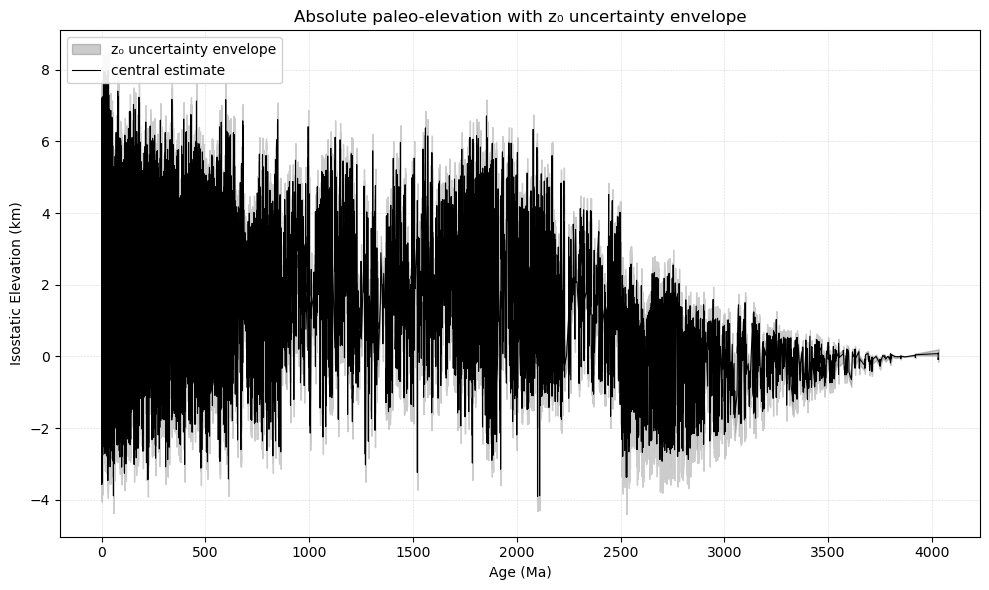


✅ Results saved to: /Users/jianpingzhou/Documents/GitHub/Paleo crustal and topography/Geology 2026/Herz 0.38_processed_crustal_density_elevation.csv

📊 Preview of results:


,Age_Ma,Predicted_Crustal_Thickness,z0_min_km,z0_mid_km,z0_max_km,Elev_abs_low_km,Isostatic_Elevation_absolute_km,Elev_abs_high_km
0,0.00185,35.205173,26,29,32,0.505898,0.979411,1.452925
1,0.00185,34.998767,26,29,32,0.473319,0.946832,1.420346
2,0.00185,35.144717,26,29,32,0.496355,0.969869,1.443382
3,2749.50000,48.497445,40,45,55,-0.553159,0.297520,0.722860
4,2749.50000,46.457084,40,45,55,-0.726728,0.123951,0.549291


🔧 Suggested bin width (Ma): 50


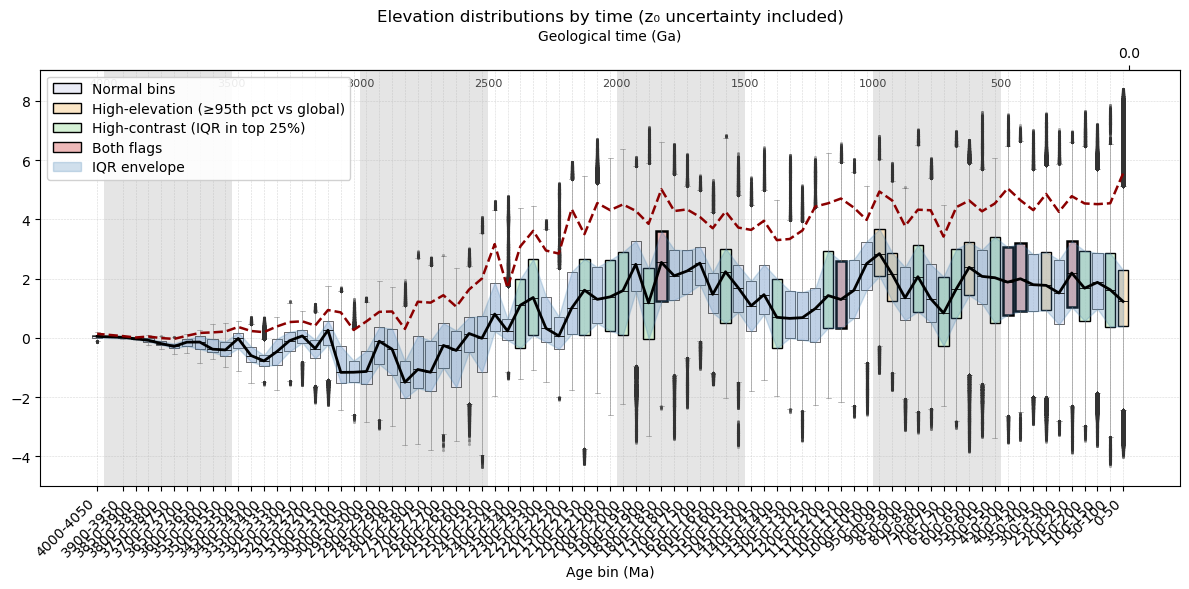

📄 Exported plots to PDF: /Users/jianpingzhou/work/Papers/paleo_elevation_plots.pdf
📄 Exported plot to SVG: /Users/jianpingzhou/work/Papers/paleo_elevation_plot_1.svg
📄 Exported plot to SVG: /Users/jianpingzhou/work/Papers/paleo_elevation_plot_2.svg


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.backends.backend_pdf import PdfPages
import chardet
import matplotlib.patches as mpatches  # used in legends/box styles
# 1) Utilities: encoding detection & temperature CSV cleaning

def detect_encoding(file_path):
    with open(file_path, 'rb') as f:
        result = chardet.detect(f.read(10000))
    return result['encoding']

def read_and_clean_temp_csv(file_path):
    encoding = detect_encoding(file_path)
    print(f"⚠️ Detected encoding: {encoding}")

    df = pd.read_csv(file_path, encoding=encoding, sep=',')
    # Normalize headers to UTF-8 and strip spaces
    df.columns = [col.encode('latin1').decode('utf-8', errors='ignore').strip() for col in df.columns]

    # If the CSV came in as a single column with commas inside headers, split it
    if len(df.columns) == 1 and ',' in df.columns[0]:
        df = df[df.columns[0]].str.split(',', expand=True)
        df.columns = ["Age_Ma", "Temperature_C"]
    elif "Temperature (¡C)" in df.columns:
        df.rename(columns={"Temperature (¡C)": "Temperature_C"}, inplace=True)

    # Rename common variants
    col_rename_dict = {
        "Age": "Age_Ma",
        "Age (Ma)": "Age_Ma",
        "Temperature (°C)": "Temperature_C",
    }
    df.rename(columns=col_rename_dict, inplace=True)

    # Ensure numeric
    df["Age_Ma"] = df["Age_Ma"].astype(float)
    df["Temperature_C"] = df["Temperature_C"].astype(float)

    print("📋 Cleaned columns:", df.columns.tolist())
    return df


# 2) Mantle temperature interpolation (robust)
def build_temperature_interp(df):
    df = df.dropna(subset=["Age_Ma", "Temperature_C"]).copy()
    df["Age_Ga"] = df["Age_Ma"] / 1000.0
    df = df.sort_values("Age_Ga").drop_duplicates(subset=["Age_Ga"])
    kind = "cubic" if df.shape[0] >= 4 else "linear"
    return interp1d(df["Age_Ga"], df["Temperature_C"], kind=kind, fill_value="extrapolate")

# 3) Densities (temperature-dependent)
def rho_cc_temp_dependent(t, Tp_func, rho0=2880, rho_oc=3320, alpha=2.5e-5, T0=300):
    """
    Continental crust density with a gradual transition toward oceanic values after 2.0 Ga,
    and thermal expansion correction with coefficient alpha.
    """
    if t < 2.0:
        base_rho = rho0
    else:
        f1 = (t - 2.0) / 1.5
        base_rho = (1 - f1) * rho0 + f1 * rho_oc
    T = float(Tp_func(t))
    delta_T = T - T0
    return base_rho * (1 - alpha * delta_T)

def rho_cl(t, Tp_func, rho0=3330.0, alpha=3e-5, T0=1350.0):
    """Lithospheric mantle density with thermal expansion."""
    T = float(Tp_func(t))
    delta_T = T - T0
    return rho0 * (1 - alpha * delta_T)
# 4) z0 uncertainty handling (bounds, central, envelope)

def dynamic_z0_bounds(age_Ga, non_archean=(26.0, 32.0), archean=(40.0, 55.0), cutoff_Ga=2.5):
    return (archean if age_Ga > cutoff_Ga else non_archean)

def dynamic_z0_central(age_Ga, non_archean_c=29.0, archean_c=45.0, cutoff_Ga=2.5):
    return (archean_c if age_Ga > cutoff_Ga else non_archean_c)

def add_z0_uncertainty_band(
    df,
    Hc_col="Predicted_Crustal_Thickness",
    age_Ma_col="Age_Ma",
    rho_c_col="Crustal_Density_kg_m3",
    rho_m_col="Lithospheric_Mantle_Density_kg_m3",
    non_archean_bounds=(26.0, 32.0),
    archean_bounds=(40.0, 55.0),
    non_archean_central=29.0,
    archean_central=45.0,
    cutoff_Ga=2.5,
    out_low_col="Elev_abs_low_km",
    out_mid_col="Isostatic_Elevation_absolute_km",
    out_high_col="Elev_abs_high_km",
    out_z0_min_col="z0_min_km",
    out_z0_mid_col="z0_mid_km",
    out_z0_max_col="z0_max_km",
):
    req = [Hc_col, age_Ma_col, rho_c_col, rho_m_col]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns needed for elevation band: {missing}")

    age_Ga = df[age_Ma_col].astype(float) / 1000.0
    Hc     = df[Hc_col].astype(float)
    rho_c  = df[rho_c_col].astype(float)
    rho_m  = df[rho_m_col].astype(float)

    z0_min, z0_mid, z0_max = [], [], []
    for t in age_Ga:
        zmin, zmax = dynamic_z0_bounds(t, non_archean_bounds, archean_bounds, cutoff_Ga)
        z0_min.append(zmin)
        z0_max.append(zmax)
        z0_mid.append(dynamic_z0_central(t, non_archean_central, archean_central, cutoff_Ga))

    z0_min = np.asarray(z0_min)
    z0_mid = np.asarray(z0_mid)
    z0_max = np.asarray(z0_max)
    scale  = (rho_m - rho_c) / rho_m

    df[out_z0_min_col] = z0_min
    df[out_z0_mid_col] = z0_mid
    df[out_z0_max_col] = z0_max

    df[out_low_col]  = (Hc - z0_max) * scale    # lowest plausible elevation
    df[out_mid_col]  = (Hc - z0_mid) * scale    # central estimate
    df[out_high_col] = (Hc - z0_min) * scale    # highest plausible elevation
    return df
# 5) Numeric equal-width geologic time bands (4000 -> 0 Ma)
def draw_numeric_equal_bands(
    ax,
    age_min_ma,
    age_max_ma,
    step_ma=500.0,
    alpha=0.10,
    label=True,
    label_size=8,
    label_inside=True
):
    """
    Shades equal-width vertical bands between 4000 and 0 Ma.
    Labels bands with a single number at the *older* edge (e.g., 2500, 2250, 2000).
    Alternates light fills for readability.
    """
    lo = float(min(age_min_ma, age_max_ma))
    hi = float(max(age_min_ma, age_max_ma))

    start = 0.0
    end   = 4000.0
    edges = np.arange(end, start - 1e-9, -step_ma)

    for i in range(len(edges) - 1):
        a0, a1 = edges[i], edges[i+1]

        left  = max(min(a0, a1), lo)
        right = min(max(a0, a1), hi)
        if right <= left:
            continue

        # Alternate subtle shading
        if i % 2 == 0:
            ax.axvspan(a0, a1, color="#000000", alpha=alpha, ec="none", zorder=0)

        # Label only with the *older* edge value
        if label:
            xmid = a0  # position label at older boundary
            y = 0.98 if label_inside else 1.01
            ax.text(
                xmid, y, f"{int(a0)}",
                ha="center",
                va=("top" if label_inside else "bottom"),
                transform=ax.get_xaxis_transform(),
                fontsize=label_size,
                color="0.25",
                zorder=1
            )
# 6) Robust top-axis in Ga (secondary_xaxis or twiny)

def add_top_ga_axis(ax, positions, ga_tick_step=None, label="Geological time (Ga)"):
    ma_min, ma_max = float(min(positions)), float(max(positions))
    ga_min, ga_max = ma_min/1000.0, ma_max/1000.0
    ga_range = abs(ga_max - ga_min)
    if ga_tick_step is None:
        if   ga_range >= 2.0: step = 0.5
        elif ga_range >= 1.0: step = 0.25
        elif ga_range >= 0.5: step = 0.1
        else:                 step = 0.05
    else:
        step = float(ga_tick_step)

    lo = np.floor(min(ga_min, ga_max)/step)*step
    hi = np.ceil (max(ga_min, ga_max)/step)*step
    ga_ticks = np.arange(lo, hi + 1e-12, step)
    ma_tick_positions = ga_ticks * 1000.0

    # Try secondary_xaxis (Matplotlib ≥ 3.1)
    has_secondary = False
    try:
        import matplotlib
        v = matplotlib.__version__.split(".")
        has_secondary = (int(v[0]) > 3) or (int(v[0]) == 3 and int(v[1]) >= 1)
    except Exception:
        has_secondary = False

    if has_secondary:
        _ma_to_ga = lambda x: np.asarray(x) / 1000.0
        _ga_to_ma = lambda x: np.asarray(x) * 1000.0
        ax_top = ax.secondary_xaxis('top', functions=(_ma_to_ga, _ga_to_ma))
        ax_top.set_xticks(ma_tick_positions)
        ax_top.set_xticklabels([f"{g:.2f}" if step < 0.5 else f"{g:.1f}" for g in ga_ticks])
        ax_top.set_xlabel(label)
    else:
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(ma_tick_positions)
        ax_top.set_xticklabels([f"{g:.2f}" if step < 0.5 else f"{g:.1f}" for g in ga_ticks])
        ax_top.set_xlabel(label)

    fig = ax.get_figure()
    fig.subplots_adjust(top=0.86)
    return ax_top
def add_top_ga_axis(ax, positions, ga_tick_step=None, label="Geological time (Ga)"):
    ma_min, ma_max = float(min(positions)), float(max(positions))
    ga_min, ga_max = ma_min/1000.0, ma_max/1000.0
    ga_range = abs(ga_max - ga_min)
    if ga_tick_step is None:
        if   ga_range >= 2.0: step = 0.5
        elif ga_range >= 1.0: step = 0.25
        elif ga_range >= 0.5: step = 0.1
        else:                 step = 0.05
    else:
        step = float(ga_tick_step)

    lo = np.floor(min(ga_min, ga_max)/step)*step
    hi = np.ceil (max(ga_min, ga_max)/step)*step
    ga_ticks = np.arange(lo, hi + 1e-12, step)
    ma_tick_positions = ga_ticks * 1000.0

    # Try secondary_xaxis (Matplotlib ≥ 3.1)
    has_secondary = False
    try:
        import matplotlib
        v = matplotlib.__version__.split(".")
        has_secondary = (int(v[0]) > 3) or (int(v[0]) == 3 and int(v[1]) >= 1)
    except Exception:
        has_secondary = False

    if has_secondary:
        _ma_to_ga = lambda x: np.asarray(x) / 1000.0
        _ga_to_ma = lambda x: np.asarray(x) * 1000.0
        ax_top = ax.secondary_xaxis('top', functions=(_ma_to_ga, _ga_to_ma))
        ax_top.set_xticks(ma_tick_positions)
        ax_top.set_xticklabels([f"{g:.2f}" if step < 0.5 else f"{g:.1f}" for g in ga_ticks])
        ax_top.set_xlabel(label)
    else:
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(ma_tick_positions)
        ax_top.set_xticklabels([f"{g:.2f}" if step < 0.5 else f"{g:.1f}" for g in ga_ticks])
        ax_top.set_xlabel(label)

    fig = ax.get_figure()
    fig.subplots_adjust(top=0.86)
    return ax_top

# 7) Bin width suggestion + time-binned box plot (numeric bands + hairline styles)
def suggest_time_bin_width(ages_Ma, rule="fd"):
    ages = pd.Series(ages_Ma).dropna().astype(float)
    if ages.empty:
        return 50.0
    data_range = ages.max() - ages.min()
    n = len(ages)
    if rule.lower() == "sturges":
        k = np.ceil(np.log2(n) + 1)
    elif rule.lower() == "sqrt":
        k = np.ceil(np.sqrt(n))
    else:
        iqr = np.subtract(*np.percentile(ages, [75, 25]))
        if iqr == 0:
            k = np.ceil(np.sqrt(n))
        else:
            h = 2 * iqr / (n ** (1/3))
            k = np.clip(np.ceil(data_range / h), 5, 100)
    k = max(int(k), 1)
    width = max(data_range / k, 1.0)
    scale = 10 ** np.floor(np.log10(width))
    for m in [1, 2, 5, 10]:
        if width <= m * scale:
            return float(m * scale)
    return float(10 * scale)

def time_binned_boxplot(
    df,
    elevation_col="Isostatic_Elevation_absolute_km",
    age_col="Age_Ma",
    bin_width_Ma=100, # set None when let the code choose automatically
    bin_rule="fd",
    min_bin_count=15,
    show_outliers=True,
    iqr_flag_quantile=0.75,
    high_elev_quantile=0.95,  # << default now 95%
    label_stride=1,
    figsize=(12, 6),
    title=None,
    ax=None,
    return_stats=True,
    # display options
    invert_x=True,
    add_top_ga_axis_flag=True,
    ga_tick_step=None,
    # Numeric bands (4000->0 Ma) instead of ICS words
    add_numeric_bands=True,
    numeric_band_step_ma=500.0,
    numeric_band_alpha=0.10,
    numeric_band_label=True,
    numeric_band_label_size=8,
):
    if age_col not in df.columns or elevation_col not in df.columns:
        raise KeyError(f"'{age_col}' or '{elevation_col}' not found in DataFrame.")

    work = df[[age_col, elevation_col]].dropna().copy().astype({age_col: float, elevation_col: float})
    if work.empty:
        raise ValueError("No valid data to plot.")

    if bin_width_Ma is None:
        bin_width_Ma = suggest_time_bin_width(work[age_col], rule=bin_rule)

    a_min, a_max = work[age_col].min(), work[age_col].max()
    start_edge = np.floor(a_min / bin_width_Ma) * bin_width_Ma
    end_edge   = np.ceil(a_max / bin_width_Ma) * bin_width_Ma
    edges = np.arange(start_edge, end_edge + bin_width_Ma, bin_width_Ma, dtype=float)
    if len(edges) < 2:
        edges = np.array([a_min, a_max])

    bin_ids = np.digitize(work[age_col].values, edges, right=False) - 1
    work["__bin_id__"] = bin_ids
    valid_mask = (bin_ids >= 0) & (bin_ids < len(edges) - 1)
    work = work.loc[valid_mask]

    global_high_q = np.quantile(work[elevation_col], high_elev_quantile)
    iqr_per_bin = work.groupby("__bin_id__")[elevation_col].apply(
        lambda s: np.subtract(*np.percentile(s, [75, 25]))
    )
    iqr_thresh = np.quantile(iqr_per_bin.values, iqr_flag_quantile) if len(iqr_per_bin) else np.nan

    bin_data, positions, labels, stats_rows = [], [], [], []
    centers = (edges[:-1] + edges[1:]) / 2.0
    for b in range(len(edges) - 1):
        subset = work.loc[work["__bin_id__"] == b, elevation_col].values
        cnt = subset.size
        if cnt < min_bin_count:
            continue
        q1, med, q3 = np.percentile(subset, [25, 50, 75])
        iqr = q3 - q1
        p95  = np.quantile(subset, 0.95)
        p_hi = np.quantile(subset, high_elev_quantile)  # dynamic, matches legend/flagging
        p99  = np.quantile(subset, 0.99)
        high_contrast = bool(iqr >= iqr_thresh) if not np.isnan(iqr_thresh) else False
        high_elev     = bool(p_hi >= global_high_q)
        bin_data.append(subset)
        positions.append(centers[b])
        labels.append(f"{edges[b]:.0f}-{edges[b+1]:.0f}")
        stats_rows.append({
            "bin_left_Ma": edges[b], "bin_right_Ma": edges[b+1], "bin_center_Ma": centers[b],
            "count": cnt, "median_km": med, "q1_km": q1, "q3_km": q3, "iqr_km": iqr,
            "p95_km": p95, f"p{int(high_elev_quantile*100)}_km": p_hi, "p99_km": p99,
            "min_km": np.min(subset), "max_km": np.max(subset),
            "flag_high_contrast": high_contrast, "flag_high_elevation": high_elev
        })

    if not bin_data:
        raise ValueError("No bins met min_bin_count—use wider bins or lower min_bin_count.")

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.get_figure()

    # === Numeric equal-width bands (no ICS words) ===
    if add_numeric_bands:
        ma_min, ma_max = float(min(positions)), float(max(positions))
        draw_numeric_equal_bands(
            ax,
            age_min_ma=ma_min,
            age_max_ma=ma_max,
            step_ma=numeric_band_step_ma,
            alpha=numeric_band_alpha,
            label=numeric_band_label,
            label_size=numeric_band_label_size,
            label_inside=True
        )

def add_top_ga_axis(ax, positions, ga_tick_step=None, label="Geological time (Ga)"):
    ma_min, ma_max = float(min(positions)), float(max(positions))
    ga_min, ga_max = ma_min/1000.0, ma_max/1000.0
    ga_range = abs(ga_max - ga_min)
    if ga_tick_step is None:
        if   ga_range >= 2.0: step = 0.5
        elif ga_range >= 1.0: step = 0.25
        elif ga_range >= 0.5: step = 0.1
        else:                 step = 0.05
    else:
        step = float(ga_tick_step)

    lo = np.floor(min(ga_min, ga_max)/step)*step
    hi = np.ceil (max(ga_min, ga_max)/step)*step
    ga_ticks = np.arange(lo, hi + 1e-12, step)
    ma_tick_positions = ga_ticks * 1000.0

    # Try secondary_xaxis (Matplotlib ≥ 3.1)
    has_secondary = False
    try:
        import matplotlib
        v = matplotlib.__version__.split(".")
        has_secondary = (int(v[0]) > 3) or (int(v[0]) == 3 and int(v[1]) >= 1)
    except Exception:
        has_secondary = False

    if has_secondary:
        _ma_to_ga = lambda x: np.asarray(x) / 1000.0
        _ga_to_ma = lambda x: np.asarray(x) * 1000.0
        ax_top = ax.secondary_xaxis('top', functions=(_ma_to_ga, _ga_to_ma))
        ax_top.set_xticks(ma_tick_positions)
        ax_top.set_xticklabels([f"{g:.2f}" if step < 0.5 else f"{g:.1f}" for g in ga_ticks])
        ax_top.set_xlabel(label)
    else:
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(ma_tick_positions)
        ax_top.set_xticklabels([f"{g:.2f}" if step < 0.5 else f"{g:.1f}" for g in ga_ticks])
        ax_top.set_xlabel(label)

    fig = ax.get_figure()
    fig.subplots_adjust(top=0.86)
    return ax_top

def suggest_time_bin_width(ages_Ma, rule="fd"):
    ages = pd.Series(ages_Ma).dropna().astype(float)
    if ages.empty:
        return 50.0
    data_range = ages.max() - ages.min()
    n = len(ages)
    if rule.lower() == "sturges":
        k = np.ceil(np.log2(n) + 1)
    elif rule.lower() == "sqrt":
        k = np.ceil(np.sqrt(n))
    else:
        iqr = np.subtract(*np.percentile(ages, [75, 25]))
        if iqr == 0:
            k = np.ceil(np.sqrt(n))
        else:
            h = 2 * iqr / (n ** (1/3))
            k = np.clip(np.ceil(data_range / h), 5, 100)
    k = max(int(k), 1)
    width = max(data_range / k, 1.0)
    scale = 10 ** np.floor(np.log10(width))
    for m in [1, 2, 5, 10]:
        if width <= m * scale:
            return float(m * scale)
    return float(10 * scale)

def time_binned_boxplot(
    df,
    elevation_col="Isostatic_Elevation_absolute_km",
    age_col="Age_Ma",
    bin_width_Ma=100, # set None when let the code choose automatically
    bin_rule="fd",
    min_bin_count=15,
    show_outliers=True,
    iqr_flag_quantile=0.75,
    high_elev_quantile=0.95,  # << default now 95%
    label_stride=1,
    figsize=(12, 6),
    title=None,
    ax=None,
    return_stats=True,
    # display options
    invert_x=True,
    add_top_ga_axis_flag=True,
    ga_tick_step=None,
    # Numeric bands (4000->0 Ma) instead of ICS words
    add_numeric_bands=True,
    numeric_band_step_ma=500.0,
    numeric_band_alpha=0.10,
    numeric_band_label=True,
    numeric_band_label_size=8,
):
    if age_col not in df.columns or elevation_col not in df.columns:
        raise KeyError(f"'{age_col}' or '{elevation_col}' not found in DataFrame.")

    work = df[[age_col, elevation_col]].dropna().copy().astype({age_col: float, elevation_col: float})
    if work.empty:
        raise ValueError("No valid data to plot.")

    if bin_width_Ma is None:
        bin_width_Ma = suggest_time_bin_width(work[age_col], rule=bin_rule)

    a_min, a_max = work[age_col].min(), work[age_col].max()
    start_edge = np.floor(a_min / bin_width_Ma) * bin_width_Ma
    end_edge   = np.ceil(a_max / bin_width_Ma) * bin_width_Ma
    edges = np.arange(start_edge, end_edge + bin_width_Ma, bin_width_Ma, dtype=float)
    if len(edges) < 2:
        edges = np.array([a_min, a_max])

    bin_ids = np.digitize(work[age_col].values, edges, right=False) - 1
    work["__bin_id__"] = bin_ids
    valid_mask = (bin_ids >= 0) & (bin_ids < len(edges) - 1)
    work = work.loc[valid_mask]

    global_high_q = np.quantile(work[elevation_col], high_elev_quantile)
    iqr_per_bin = work.groupby("__bin_id__")[elevation_col].apply(
        lambda s: np.subtract(*np.percentile(s, [75, 25]))
    )
    iqr_thresh = np.quantile(iqr_per_bin.values, iqr_flag_quantile) if len(iqr_per_bin) else np.nan

    bin_data, positions, labels, stats_rows = [], [], [], []
    centers = (edges[:-1] + edges[1:]) / 2.0
    for b in range(len(edges) - 1):
        subset = work.loc[work["__bin_id__"] == b, elevation_col].values
        cnt = subset.size
        if cnt < min_bin_count:
            continue
        q1, med, q3 = np.percentile(subset, [25, 50, 75])
        iqr = q3 - q1
        p95  = np.quantile(subset, 0.95)
        p_hi = np.quantile(subset, high_elev_quantile)  # dynamic, matches legend/flagging
        p99  = np.quantile(subset, 0.99)
        high_contrast = bool(iqr >= iqr_thresh) if not np.isnan(iqr_thresh) else False
        high_elev     = bool(p_hi >= global_high_q)
        bin_data.append(subset)
        positions.append(centers[b])
        labels.append(f"{edges[b]:.0f}-{edges[b+1]:.0f}")
        stats_rows.append({
            "bin_left_Ma": edges[b], "bin_right_Ma": edges[b+1], "bin_center_Ma": centers[b],
            "count": cnt, "median_km": med, "q1_km": q1, "q3_km": q3, "iqr_km": iqr,
            "p95_km": p95, f"p{int(high_elev_quantile*100)}_km": p_hi, "p99_km": p99,
            "min_km": np.min(subset), "max_km": np.max(subset),
            "flag_high_contrast": high_contrast, "flag_high_elevation": high_elev
        })

    if not bin_data:
        raise ValueError("No bins met min_bin_count—use wider bins or lower min_bin_count.")

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.get_figure()

    # === Numeric equal-width bands (no ICS words) ===
    if add_numeric_bands:
        ma_min, ma_max = float(min(positions)), float(max(positions))
        draw_numeric_equal_bands(
            ax,
            age_min_ma=ma_min,
            age_max_ma=ma_max,
            step_ma=numeric_band_step_ma,
            alpha=numeric_band_alpha,
            label=numeric_band_label,
            label_size=numeric_band_label_size,
            label_inside=True
        )

    # === Box plot with hairline defaults, thin dots ===
    base_lw = 0.4       # hairline baseline for boxes/whiskers/caps
    med_lw  = 0.6       # median line
    out_ms  = 2.0       # outlier marker size
    out_mew = 0.2       # outlier edge width

    bp = ax.boxplot(
        bin_data,
        positions=positions,
        widths=0.8 * bin_width_Ma,
        patch_artist=True,
        showfliers=show_outliers,
        manage_ticks=False,
        flierprops=dict(
            marker='o',
            markersize=out_ms,
            markerfacecolor="0.2",
            markeredgecolor="0.2",
            markeredgewidth=out_mew,
            alpha=0.35
        ),
        boxprops=dict(linewidth=base_lw, edgecolor="black"),
        whiskerprops=dict(linewidth=base_lw, color="0.5"),
        capprops=dict(linewidth=base_lw, color="0.5"),
        medianprops=dict(linewidth=med_lw, color="black"),
    )

    # Progressive thickening only when flagged
    stats_df = pd.DataFrame(stats_rows)
    # ------------------------------------------------------------
    # Overlay statistics curves (Median, IQR band, P95)
    # ------------------------------------------------------------

    centers = stats_df["bin_center_Ma"].values
    median  = stats_df["median_km"].values
    q1      = stats_df["q1_km"].values
    q3      = stats_df["q3_km"].values
    p95     = stats_df["p95_km"].values

    # IQR shading (Q1–Q3)
    ax.fill_between(
        centers,
        q1,
        q3,
        color="steelblue",
        alpha=0.25,
        label="IQR (25–75%)",
        zorder=2
    )

    # Median trend
    ax.plot(
        centers,
        median,
        color="black",
        linewidth=2.0,
        label="Median elevation",
        zorder=3
    )

    # P95 trend
    ax.plot(
        centers,
        p95,
        color="darkred",
        linestyle="--",
        linewidth=1.8,
        label="95th percentile",
        zorder=3
    )
    normal_face   = (0.85, 0.87, 0.95, 0.55)
    elev_face     = (0.98, 0.87, 0.70, 0.75)  # high-elevation
    contrast_face = (0.78, 0.93, 0.78, 0.75)  # high-contrast
    both_face     = (0.92, 0.68, 0.68, 0.85)  # both flags

    edge_lw_normal   = base_lw
    edge_lw_elev     = 1.0
    edge_lw_contrast = 1.0
    edge_lw_both     = 1.8

    for patch, (_, row) in zip(bp["boxes"], stats_df.reset_index(drop=True).iterrows()):
        if row["flag_high_elevation"] and row["flag_high_contrast"]:
            face, lw = both_face, edge_lw_both
        elif row["flag_high_elevation"]:
            face, lw = elev_face, edge_lw_elev
        elif row["flag_high_contrast"]:
            face, lw = contrast_face, edge_lw_contrast
        else:
            face, lw = normal_face, edge_lw_normal
        patch.set_facecolor(face)
        patch.set_edgecolor("black")
        patch.set_linewidth(lw)

    # X ticks (Ma)
    ax.set_xticks(positions[::label_stride])
    ax.set_xticklabels([labels[i] for i in range(0, len(labels), label_stride)], rotation=45, ha="right")
    ax.set_xlabel("Age bin (Ma)")

    # Older to the left
    if invert_x:
        ax.invert_xaxis()

    # Top Ga axis
    if add_top_ga_axis_flag:
        _ = add_top_ga_axis(ax, positions, ga_tick_step=ga_tick_step)

    if title is None:
        title = f"Elevation distribution through time (bin = {bin_width_Ma:.0f} Ma)"
    ax.set_title(title)

    # Subtle grid
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

    # Legend moved to top-left to avoid overlap (auto-uses the chosen percentile)
    hi_label_pct = int(high_elev_quantile * 100)
    handles = [
        mpatches.Patch(facecolor=normal_face, edgecolor="black", label="Normal bins"),
        mpatches.Patch(facecolor=elev_face, edgecolor="black",
                       label=f"High-elevation (≥{hi_label_pct}th pct vs global)"),
        mpatches.Patch(facecolor=contrast_face, edgecolor="black",
                       label=f"High-contrast (IQR in top {int((1-iqr_flag_quantile)*100)}%)"),
        mpatches.Patch(facecolor=both_face, edgecolor="black", label="Both flags"),
        mpatches.Patch(color="steelblue", alpha=0.25, label="IQR envelope"),
    ]
    ax.legend(
        handles=handles,
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        borderpad=0.4,
        labelspacing=0.4
    )

    fig.tight_layout()
    if created_fig:
        plt.show()

    return (stats_df if return_stats else None), fig, ax

def monte_carlo_elevation_from_z0(
    df,
    n_draws=200,
    sampler="triangular",
    age_Ma_col="Age_Ma",
    Hc_col="Predicted_Crustal_Thickness",
    rho_c_col="Crustal_Density_kg_m3",
    rho_m_col="Lithospheric_Mantle_Density_kg_m3",
    z0_min_col="z0_min_km",
    z0_mid_col="z0_mid_km",
    z0_max_col="z0_max_km",
    out_age_col="Age_Ma",
    out_elev_col="Elevation_MC_km"
):
    req = [age_Ma_col, Hc_col, rho_c_col, rho_m_col, z0_min_col, z0_mid_col, z0_max_col]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for MC sampling: {missing}")

    ages = df[age_Ma_col].astype(float).values
    Hc   = df[Hc_col].astype(float).values
    rho_c = df[rho_c_col].astype(float).values
    rho_m = df[rho_m_col].astype(float).values
    zmin = df[z0_min_col].astype(float).values
    zmid = df[z0_mid_col].astype(float).values
    zmax = df[z0_max_col].astype(float).values
    scale = (rho_m - rho_c) / rho_m

    rng = np.random.default_rng()
    parts = []
    for i in range(len(df)):
        if sampler == "uniform":
            z0 = rng.uniform(zmin[i], zmax[i], size=n_draws)
        else:
            left, mode, right = zmin[i], zmid[i], zmax[i]
            if not (right >= mode >= left) or right == left:
                z0 = np.full(n_draws, zmid[i])
            else:
                z0 = rng.triangular(left, mode, right, size=n_draws)
        elev = (Hc[i] - z0) * scale[i]
        parts.append(pd.DataFrame({out_age_col: ages[i], out_elev_col: elev}))
    return pd.concat(parts, ignore_index=True)

def plot_elevation_with_z0_band(
    df,
    age_col="Age_Ma",
    y_low_col="Elev_abs_low_km",
    y_mid_col="Isostatic_Elevation_absolute_km",
    y_high_col="Elev_abs_high_km",
    title="Absolute paleo-elevation with z₀ uncertainty envelope",
    figsize=(10,6)
):
    xx = df[age_col].astype(float).values
    order = np.argsort(xx)
    x = xx[order]
    y_low  = df[y_low_col].values[order]
    y_mid  = df[y_mid_col].values[order]
    y_high = df[y_high_col].values[order]

    fig, ax = plt.subplots(figsize=figsize)
    # Subtle gray envelope and hairline central curve
    ax.fill_between(x, y_low, y_high, alpha=0.20, color="#000000", label="z₀ uncertainty envelope")
    ax.plot(x, y_mid, linewidth=0.8, color="black", label="central estimate")
    ax.set_xlabel("Age (Ma)")
    ax.set_ylabel("Isostatic Elevation (km)")
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    ax.legend(loc="upper left", frameon=True, framealpha=0.9)
    fig.tight_layout()
    plt.show()
    return fig, ax

def process_crustal_data():
    # --- Update these paths if needed ---
    temp_csv = "/Users/jianpingzhou/work/Papers/Geology/Trainining dataset/Herzberg_2010_Ur 0.38_Age_Temperature_Averaged.csv"
    crust_data_path = "/Users/jianpingzhou/Documents/GitHub/Paleo crustal and topography/Geology 2026/Continental paleo-crustal thickness dataset for Geology.csv"

    if not os.path.exists(temp_csv) or not os.path.exists(crust_data_path):
        print("❌ One or more input files do not exist.")
        return None, None

    # Mantle temperature interpolation
    temp_df = read_and_clean_temp_csv(temp_csv)
    Tp_func = build_temperature_interp(temp_df)

    # Load crustal data
    crust_df = pd.read_csv(crust_data_path)
    if "Age_Ma" not in crust_df.columns or "Predicted_Crustal_Thickness" not in crust_df.columns:
        raise KeyError("❌ 'Age_Ma' or 'Predicted_Crustal_Thickness' column is missing.")

    crust_df["Age_Ga"] = crust_df["Age_Ma"].astype(float) / 1000.0

    # Temperature-dependent densities
    crust_df["Mantle_Temperature_C"] = crust_df["Age_Ga"].apply(Tp_func)
    crust_df["Crustal_Density_kg_m3"] = crust_df["Age_Ga"].apply(lambda t: rho_cc_temp_dependent(t, Tp_func))
    crust_df["Lithospheric_Mantle_Density_kg_m3"] = crust_df["Age_Ga"].apply(lambda t: rho_cl(t, Tp_func))

    # z0 uncertainty and absolute elevation envelope
    crust_df = add_z0_uncertainty_band(
        crust_df,
        Hc_col="Predicted_Crustal_Thickness",
        age_Ma_col="Age_Ma",
        rho_c_col="Crustal_Density_kg_m3",
        rho_m_col="Lithospheric_Mantle_Density_kg_m3",
        non_archean_bounds=(26, 32),
        archean_bounds=(40, 55),
        non_archean_central=29,
        archean_central=45,
        cutoff_Ga=2.5,
        out_low_col="Elev_abs_low_km",
        out_mid_col="Isostatic_Elevation_absolute_km",
        out_high_col="Elev_abs_high_km",
        out_z0_min_col="z0_min_km",
        out_z0_mid_col="z0_mid_km",
        out_z0_max_col="z0_max_km",
    )

    # Plot the envelope and collect the figure
    fig_env, ax_env = plot_elevation_with_z0_band(crust_df)

    # Save processed CSV next to the source crust data
    crust_df.drop(columns=["Age_Ga"], inplace=True)
    output_path_dir = os.path.dirname(crust_data_path)
    csv_out = os.path.join(output_path_dir, "Herz 0.38_processed_crustal_density_elevation.csv")
    crust_df.to_csv(csv_out, index=False)
    print("\n✅ Results saved to:", csv_out)

    # Small preview for sanity check (only if running in a notebook)
    try:
        from IPython.display import display
        print("\n📊 Preview of results:")
        preview_cols = [
            "Age_Ma", "Predicted_Crustal_Thickness",
            "z0_min_km", "z0_mid_km", "z0_max_km",
            "Elev_abs_low_km", "Isostatic_Elevation_absolute_km", "Elev_abs_high_km"
        ]
        display(crust_df[preview_cols].head())
    except Exception:
        pass

    return crust_df, fig_env

if __name__ == "__main__":
    df_result, fig_env = process_crustal_data()

    figs_to_save = []
    if fig_env is not None:
        figs_to_save.append(fig_env)

    if df_result is not None and not df_result.empty:
        # Monte Carlo to propagate z0 uncertainty into distributions
        df_mc = monte_carlo_elevation_from_z0(
            df_result,
            n_draws=200,
            sampler="triangular"  # or "uniform"
        )

        # Suggested bin width and plotting
        suggested_width = suggest_time_bin_width(df_mc["Age_Ma"], rule="fd")
        print(f"🔧 Suggested bin width (Ma): {suggested_width:.0f}")
        bin_width_override = None  # set to e.g. 20 to force 20 Ma bins

        stats, fig_box, ax_box = time_binned_boxplot(
            df_mc,
            elevation_col="Elevation_MC_km",
            age_col="Age_Ma",
            bin_width_Ma=(bin_width_override or suggested_width),
            min_bin_count=40,
            show_outliers=True,
            iqr_flag_quantile=0.75,
            high_elev_quantile=0.95,   # ← 95% limit here
            label_stride=1,
            title="Elevation distributions by time (z₀ uncertainty included)",
            invert_x=True,               # older to the left
            add_top_ga_axis_flag=True,   # robust Ga top axis
            ga_tick_step=0.5,            # set None for auto

            # Numeric bands (no ICS words): 4000 -> 0 Ma, 500 Ma step
            add_numeric_bands=True,
            numeric_band_step_ma=500.0,
            numeric_band_alpha=0.10,
            numeric_band_label=True,
            numeric_band_label_size=8
        )
        figs_to_save.append(fig_box)

        # ===== Export ALL figures into one multi-page PDF =====
        out_dir = os.path.dirname("/Users/jianpingzhou/work/Papers/Herz_0.23_processed_crustal_density_elevation.csv")
        pdf_path = os.path.join(out_dir, "paleo_elevation_plots.pdf")
        with PdfPages(pdf_path) as pdf:
            for f in figs_to_save:
                pdf.savefig(f, bbox_inches="tight")
        print(f"📄 Exported plots to PDF: {pdf_path}")

        # ===== Export ALL figures into SVG files =====
        out_dir = os.path.dirname("/Users/jianpingzhou/work/Papers/Herz_0.23_processed_crustal_density_elevation.csv")

        # Create individual SVG file paths for each figure in figs_to_save
        for i, f in enumerate(figs_to_save):
            svg_path = os.path.join(out_dir, f"paleo_elevation_plot_{i+1}.svg")
            f.savefig(svg_path, format='svg', bbox_inches="tight")
            print(f"📄 Exported plot to SVG: {svg_path}")

In [4]:
# ===============================================================
# Probability that each locality exceeds thresholds
# ===============================================================

thresholds = [2.0, 3.0, 4.5]

prob_records = []

for age, group in df_mc.groupby("Age_Ma"):

    for thr in thresholds:
        p = (group["Elevation_MC_km"] >= thr).mean()

        prob_records.append({
            "Age_Ma": age,
            "Threshold_km": thr,
            "P_exceed": p
        })

prob_df = pd.DataFrame(prob_records)


In [5]:
# Monte-Carlo probability per original sample
def probability_per_sample(df_result, n_draws=200):

    rng = np.random.default_rng()

    probs = []

    for _, row in df_result.iterrows():

        left, mid, right = row["z0_min_km"], row["z0_mid_km"], row["z0_max_km"]

        if right == left:
            z0 = np.full(n_draws, mid)
        else:
            z0 = rng.triangular(left, mid, right, size=n_draws)

        scale = (row["Lithospheric_Mantle_Density_kg_m3"] -
                 row["Crustal_Density_kg_m3"]) / row["Lithospheric_Mantle_Density_kg_m3"]

        elev = (row["Predicted_Crustal_Thickness"] - z0) * scale

        probs.append({
            "Age_Ma": row["Age_Ma"],
            "Lon": row["Lon"],
            "Lat": row["Lat"],
            "P2": np.mean(elev >= 2.0),
            "P3": np.mean(elev >= 3.0),
            "P45": np.mean(elev >= 4.5),
        })

    return pd.DataFrame(probs)


In [6]:
prob_samples = probability_per_sample(df_result)


In [7]:
# =========================
# Runner: Extremes + Violin/ECDF with top Age panel
# (Execute AFTER Block 1)
# =========================

🔧 Using bin width (Ma): 50
📊 Global 95th percentile:  4.580 km
📊 Global 97.5th percentile: 5.359 km


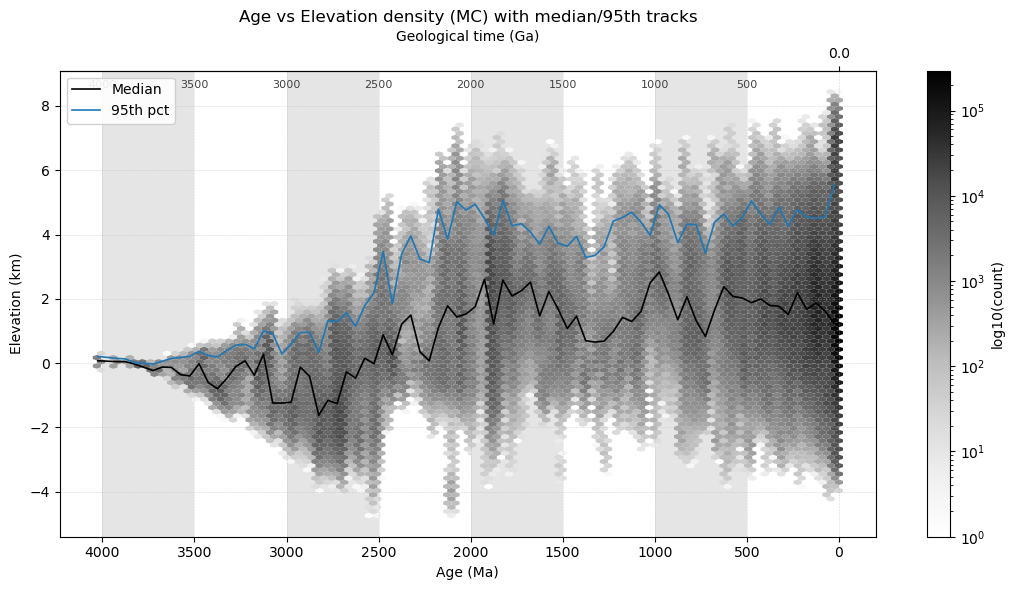

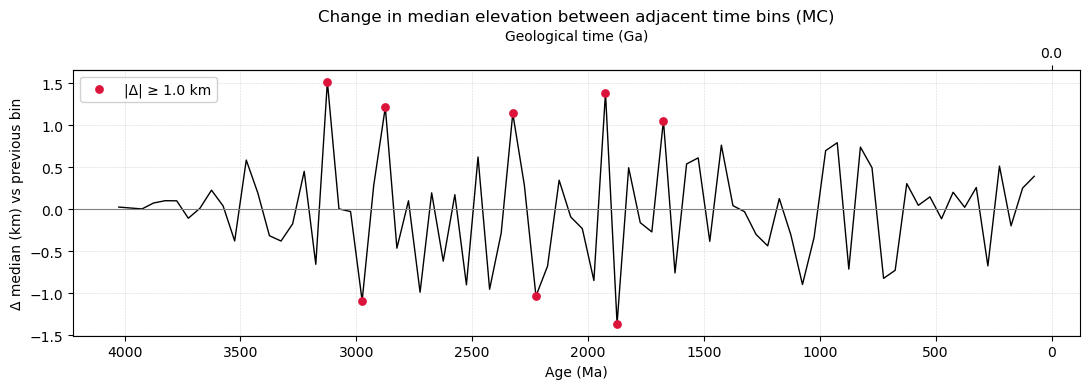

— Selection sizes —
REL 95%: 22
REL 97.5%: 9
ABS 4.0 km (frac_only, frac≥0.10): 13


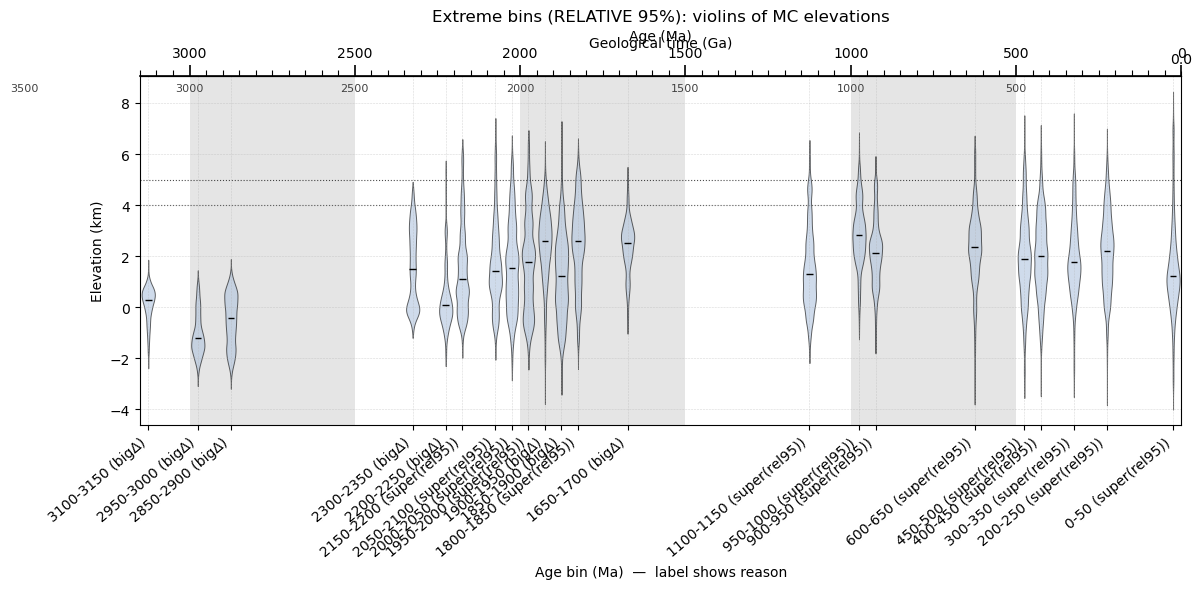

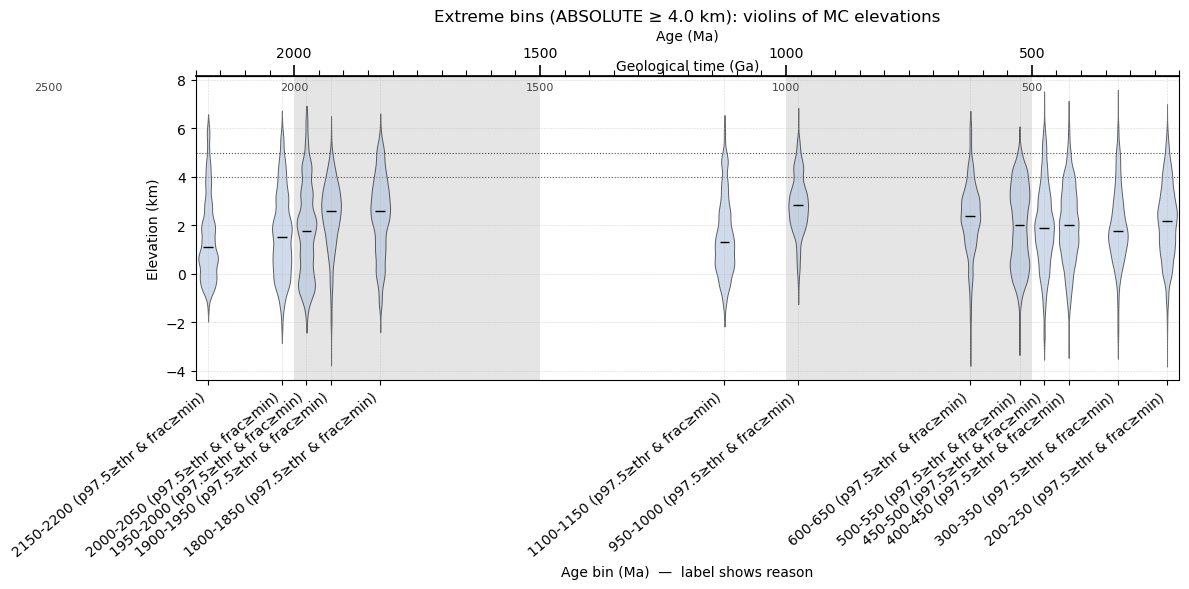

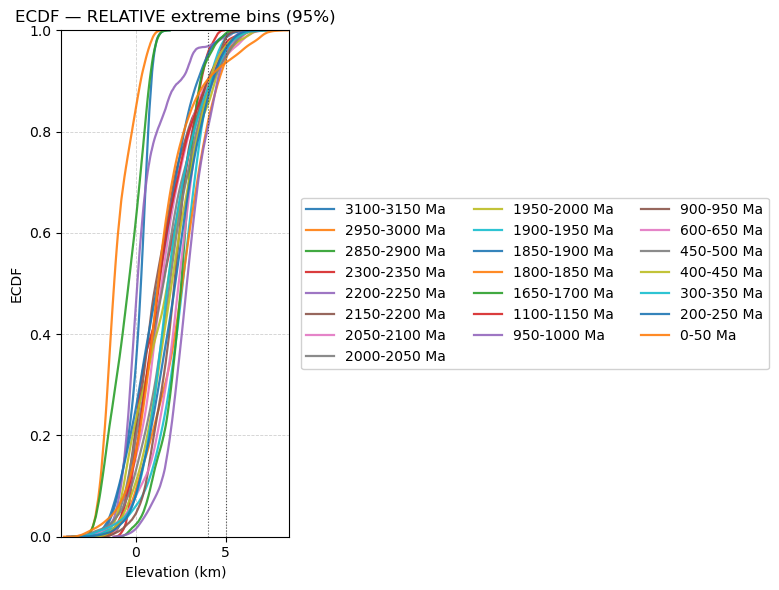

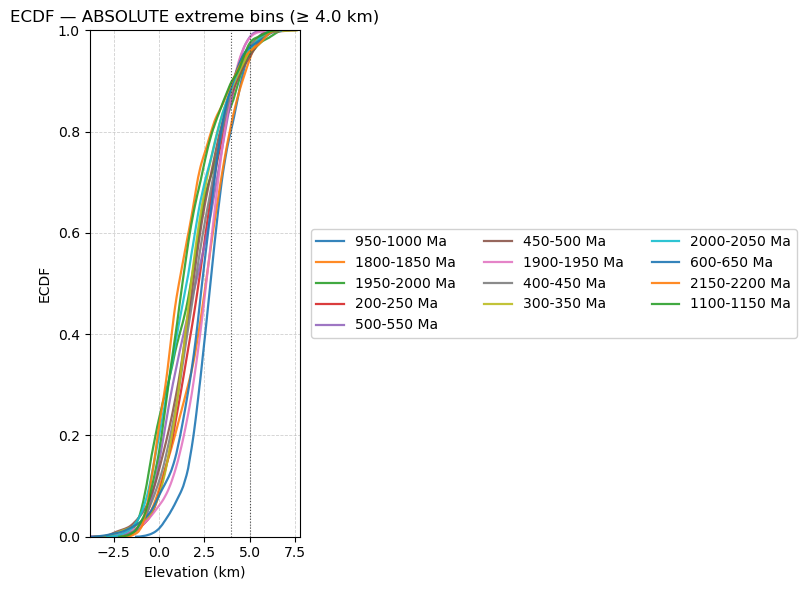

📄 Exported EXTREMES plots to PDF: /Users/jianpingzhou/work/Papers/paleo_elevation_extremes.pdf


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib.backends.backend_pdf import PdfPages
import os

# --- Helper: numeric Age panel at top (like your screenshot) ---
def add_age_panel_top(ax, xmin, xmax, major=500, minor=50, label="Age (Ma)"):
    ax.set_xlim(xmin, xmax)
    top = ax.secondary_xaxis('top')  # identity transform
    lo, hi = sorted([xmin, xmax])
    start = np.ceil(lo / major) * major
    end   = np.floor(hi / major) * major
    if start <= end:
        top.set_xticks(np.arange(start, end + 1e-9, major, dtype=float))
    top.xaxis.set_major_locator(MultipleLocator(major))
    top.xaxis.set_minor_locator(MultipleLocator(minor))
    top.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    top.tick_params(axis='x', which='major', length=8, width=1.2, direction='out')
    top.tick_params(axis='x', which='minor', length=4, width=0.8, direction='out', pad=2)
    top.spines['top'].set_linewidth(1.2)
    top.set_xlabel(label)
    return top

# --- SAFETY: ensure df_result exists and build df_mc if missing ---
if 'df_result' not in globals() or df_result is None or df_result.empty:
    raise RuntimeError("df_result is missing or empty. Please run Block 1 first.")

if 'df_mc' not in globals() or df_mc is None or df_mc.empty:
    # Build Monte Carlo draws from Block 1’s function
    df_mc = monte_carlo_elevation_from_z0(
        df_result, n_draws=200, sampler="triangular",
        age_Ma_col="Age_Ma",
        Hc_col="Predicted_Crustal_Thickness",
        rho_c_col="Crustal_Density_kg_m3",
        rho_m_col="Lithospheric_Mantle_Density_kg_m3",
        z0_min_col="z0_min_km",
        z0_mid_col="z0_mid_km",
        z0_max_col="z0_max_km",
        out_age_col="Age_Ma",
        out_elev_col="Elevation_MC_km"
    )

# --- Bin width (reuse suggestion from Block 1 if present) ---
if 'suggested_width' not in globals() or suggested_width is None:
    suggested_width = suggest_time_bin_width(df_mc["Age_Ma"], rule="fd")
bin_width_override = None  # set to a number (e.g., 20.0) to force

print(f"🔧 Using bin width (Ma): {(bin_width_override or suggested_width):.0f}")

# --- Functions from the “extremes” section (redeclare compact wrappers that call your Block 1 helpers) ---
def compute_bin_stats_only(df, elevation_col="Elevation_MC_km", age_col="Age_Ma",
                           bin_width_Ma=20.0, min_bin_count=40, iqr_flag_quantile=0.75,
                           high_q=0.975, abs_thresholds_km=(4.0,)):
    work = df[[age_col, elevation_col]].dropna().copy().astype({age_col: float, elevation_col: float})
    a_min, a_max = work[age_col].min(), work[age_col].max()
    start_edge = np.floor(a_min / bin_width_Ma) * bin_width_Ma
    end_edge   = np.ceil(a_max / bin_width_Ma) * bin_width_Ma
    edges = np.arange(start_edge, end_edge + bin_width_Ma, bin_width_Ma, dtype=float)
    if len(edges) < 2: edges = np.array([a_min, a_max], dtype=float)
    bin_ids = np.digitize(work[age_col].values, edges, right=False) - 1
    work["__bin_id__"] = bin_ids
    work = work.loc[(bin_ids >= 0) & (bin_ids < len(edges) - 1)]
    centers = (edges[:-1] + edges[1:]) / 2.0

    iqr_per_bin = work.groupby("__bin_id__")[elevation_col].apply(
        lambda s: np.subtract(*np.percentile(s, [75, 25]))
    )
    iqr_thresh = np.quantile(iqr_per_bin.values, iqr_flag_quantile) if len(iqr_per_bin) else np.nan

    rows = []
    for b in range(len(edges) - 1):
        subset = work.loc[work["__bin_id__"] == b, elevation_col].values
        if subset.size < min_bin_count: continue
        q1, med, q3 = np.percentile(subset, [25, 50, 75])
        row = {
            "bin_left_Ma": float(edges[b]),
            "bin_right_Ma": float(edges[b+1]),
            "bin_center_Ma": float(centers[b]),
            "count": int(subset.size),
            "median_km": float(med),
            "q1_km": float(q1),
            "q3_km": float(q3),
            "iqr_km": float(q3 - q1),
            "p95_km": float(np.quantile(subset, 0.95)),
            "p97_5_km": float(np.quantile(subset, high_q)),
            "p99_km": float(np.quantile(subset, 0.99)),
            "min_km": float(np.min(subset)),
            "max_km": float(np.max(subset)),
        }
        for thr in abs_thresholds_km:
            thr = float(thr)
            ge = int((subset >= thr).sum())
            row[f"count_ge_{thr:.1f}km"] = ge
            row[f"frac_ge_{thr:.1f}km"] = float(ge / subset.size)
        rows.append(row)

    stats_df = pd.DataFrame(rows).sort_values("bin_center_Ma").reset_index(drop=True)
    stats_df["delta_median_km"] = stats_df["median_km"].diff()
    stats_df["delta_p95_km"]    = stats_df["p95_km"].diff()
    stats_df["delta_p97_5_km"]  = stats_df["p97_5_km"].diff()
    return stats_df, edges, centers

def select_extreme_bins_relative(stats_df, global_high_q_value, big_jump_thresh_km=1.0):
    cond_super_full = stats_df["p95_km"] >= global_high_q_value
    cond_jump_full  = stats_df["delta_median_km"].abs() >= big_jump_thresh_km
    sel = stats_df.loc[cond_super_full | cond_jump_full].copy()
    if sel.empty: return sel
    cond_super = sel["p95_km"] >= global_high_q_value
    cond_jump  = sel["delta_median_km"].abs() >= big_jump_thresh_km
    sel["extreme_reason"] = np.where(
        cond_super & cond_jump, "super(rel95)+bigΔ",
        np.where(cond_super, "super(rel95)", "bigΔ")
    )
    return sel

def select_extreme_bins_absolute(stats_df, abs_thresh_km=4.0, min_frac_ge=0.10, rule="frac_only"):
    frac_col = f"frac_ge_{abs_thresh_km:.1f}km"
    cond_p975 = stats_df["p97_5_km"] >= abs_thresh_km
    cond_med  = stats_df["median_km"] >= abs_thresh_km
    cond_frac = stats_df[frac_col]    >= min_frac_ge
    if   rule == "frac_only":       mask = cond_frac
    elif rule == "p97_5_or_frac":   mask = cond_p975 | cond_frac
    elif rule == "median_or_frac":  mask = cond_med  | cond_frac
    elif rule == "all_three":       mask = cond_med & cond_p975 & cond_frac
    else: raise ValueError("Unknown rule")
    sel = stats_df.loc[mask].copy()
    if sel.empty: return sel
    reason = np.where(cond_frac & cond_p975, "p97.5≥thr & frac≥min",
             np.where(cond_p975, "p97.5≥thr",
             np.where(cond_frac, "frac≥min",
             np.where(cond_med, "median≥thr", "abs"))))
    sel["extreme_reason_abs"] = reason[mask.values]
    return sel

# --- Compute stats ---
abs_super_levels = (4.0, 5.0)
abs_super_level_km_for_flag = 4.0
abs_min_fraction = 0.10
abs_rule = "frac_only"

stats_only, edges_used, centers_used = compute_bin_stats_only(
    df_mc,
    elevation_col="Elevation_MC_km",
    age_col="Age_Ma",
    bin_width_Ma=(bin_width_override or suggested_width),
    min_bin_count=40,
    iqr_flag_quantile=0.75,
    high_q=0.975,
    abs_thresholds_km=abs_super_levels
)

# --- Global relative thresholds ---
global_q95  = float(np.quantile(df_mc["Elevation_MC_km"], 0.95))
global_q975 = float(np.quantile(df_mc["Elevation_MC_km"], 0.975))
print(f"📊 Global 95th percentile:  {global_q95:.3f} km")
print(f"📊 Global 97.5th percentile: {global_q975:.3f} km")

# --- Plot 1: Hexbin + quantile tracks (and SHOW) ---
figs_extra = []
fig, ax = plt.subplots(figsize=(11,6))
hb = ax.hexbin(df_mc["Age_Ma"].values, df_mc["Elevation_MC_km"].values,
               gridsize=90, bins="log", cmap="Greys", linewidths=0)
cbar = fig.colorbar(hb, ax=ax); cbar.set_label("log10(count)")
x = stats_only["bin_center_Ma"].values
ax.plot(x, stats_only["median_km"].values, lw=1.2, color="black", label="Median")
ax.plot(x, stats_only["p95_km"].values,    lw=1.2, color="tab:blue", label="95th pct")
ax.set_xlabel("Age (Ma)"); ax.set_ylabel("Elevation (km)")
ax.set_title("Age vs Elevation density (MC) with median/95th tracks")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax.legend(loc="upper left", frameon=True, framealpha=0.9)
if len(x) > 1:
    try: draw_numeric_equal_bands(ax, float(x.min()), float(x.max()), step_ma=500, alpha=0.10, label=True, label_size=8)
    except Exception: pass
    try: _ = add_top_ga_axis(ax, x, ga_tick_step=0.5)
    except Exception: pass
ax.invert_xaxis(); fig.tight_layout(); plt.show(); figs_extra.append(fig)

# --- Plot 2: Δ median (and SHOW) ---
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(stats_only["bin_center_Ma"], stats_only["delta_median_km"], lw=1.0, color="black")
ax.axhline(0, color="0.5", lw=0.8)
big = np.where(stats_only["delta_median_km"].abs().values >= 1.0)[0]
if big.size:
    ax.scatter(stats_only["bin_center_Ma"].values[big],
               stats_only["delta_median_km"].values[big], s=28, color="crimson",
               zorder=3, label="|Δ| ≥ 1.0 km")
ax.set_xlabel("Age (Ma)"); ax.set_ylabel("Δ median (km) vs previous bin")
ax.set_title("Change in median elevation between adjacent time bins (MC)")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax.legend(loc="upper left", frameon=True, framealpha=0.9)
try: _ = add_top_ga_axis(ax, stats_only["bin_center_Ma"].values, ga_tick_step=0.5)
except Exception: pass
ax.invert_xaxis(); fig.tight_layout(); plt.show(); figs_extra.append(fig)

# --- Selections ---
extreme_bins_rel95  = select_extreme_bins_relative(stats_only, global_high_q_value=global_q95,  big_jump_thresh_km=1.0)
extreme_bins_rel975 = select_extreme_bins_relative(stats_only, global_high_q_value=global_q975, big_jump_thresh_km=1.0)
extreme_bins_abs    = select_extreme_bins_absolute(stats_only, abs_thresh_km=abs_super_level_km_for_flag,
                                                   min_frac_ge=abs_min_fraction, rule=abs_rule)
print("— Selection sizes —")
print("REL 95%:", len(extreme_bins_rel95))
print("REL 97.5%:", len(extreme_bins_rel975))
print(f"ABS {abs_super_level_km_for_flag:.1f} km ({abs_rule}, frac≥{abs_min_fraction:.2f}):", len(extreme_bins_abs))

# --- Plot 3: Violins REL95 with top Age panel (and SHOW) ---
if not extreme_bins_rel95.empty:
    # prepare violin data
    data, positions, labels = [], [], []
    for _, row in extreme_bins_rel95.sort_values("bin_center_Ma", ascending=False).iterrows():
        l, r = float(row["bin_left_Ma"]), float(row["bin_right_Ma"])
        vals = df_mc.loc[(df_mc["Age_Ma"] >= l) & (df_mc["Age_Ma"] < r), "Elevation_MC_km"].dropna().values
        if vals.size < 10: continue
        data.append(vals); positions.append(float(row["bin_center_Ma"]))
        labels.append(f"{l:.0f}-{r:.0f} ({row.get('extreme_reason','')})")
    if data:
        fig, ax = plt.subplots(figsize=(12,6))
        parts = ax.violinplot(data, positions=positions, widths=0.8*(bin_width_override or suggested_width),
                              showmeans=False, showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor("lightsteelblue"); pc.set_edgecolor("black"); pc.set_alpha(0.6); pc.set_linewidth(0.7)
        parts['cmedians'].set_linewidth(1.0); parts['cmedians'].set_color("black")
        for thr in abs_super_levels: ax.axhline(thr, color="0.3", lw=0.8, ls=":", zorder=0)
        ax.set_xticks(positions); ax.set_xticklabels(labels, rotation=40, ha="right")
        ax.set_xlabel("Age bin (Ma)  —  label shows reason")
        ax.set_ylabel("Elevation (km)")
        ax.set_title("Extreme bins (RELATIVE 95%): violins of MC elevations")
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
        if len(positions) > 1:
            try: draw_numeric_equal_bands(ax, min(positions), max(positions), step_ma=500, alpha=0.10, label=True, label_size=8)
            except Exception: pass
            try: _ = add_top_ga_axis(ax, positions, ga_tick_step=0.5)
            except Exception: pass
        halfw = 0.5*(bin_width_override or suggested_width)
        add_age_panel_top(ax, min(positions)-halfw, max(positions)+halfw, major=500, minor=50, label="Age (Ma)")
        ax.invert_xaxis(); fig.tight_layout(); plt.show(); figs_extra.append(fig)
else:
    print("ℹ️ No bins met the RELATIVE (95%) extreme criteria.")

# --- Plot 4: Violins ABS with top Age panel (and SHOW) ---
if not extreme_bins_abs.empty:
    order_col = f"frac_ge_{abs_super_level_km_for_flag:.1f}km"
    tmp = extreme_bins_abs.rename(columns={"extreme_reason_abs":"extreme_reason"})
    if order_col in tmp.columns: tmp = tmp.sort_values(order_col, ascending=False)
    data, positions, labels = [], [], []
    for _, row in tmp.iterrows():
        l, r = float(row["bin_left_Ma"]), float(row["bin_right_Ma"])
        vals = df_mc.loc[(df_mc["Age_Ma"] >= l) & (df_mc["Age_Ma"] < r), "Elevation_MC_km"].dropna().values
        if vals.size < 10: continue
        data.append(vals); positions.append(float(row["bin_center_Ma"]))
        labels.append(f"{l:.0f}-{r:.0f} ({row.get('extreme_reason','')})")
    if data:
        fig, ax = plt.subplots(figsize=(12,6))
        parts = ax.violinplot(data, positions=positions, widths=0.8*(bin_width_override or suggested_width),
                              showmeans=False, showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor("lightsteelblue"); pc.set_edgecolor("black"); pc.set_alpha(0.6); pc.set_linewidth(0.7)
        parts['cmedians'].set_linewidth(1.0); parts['cmedians'].set_color("black")
        for thr in abs_super_levels: ax.axhline(thr, color="0.3", lw=0.8, ls=":", zorder=0)
        ax.set_xticks(positions); ax.set_xticklabels(labels, rotation=40, ha="right")
        ax.set_xlabel("Age bin (Ma)  —  label shows reason")
        ax.set_ylabel("Elevation (km)")
        ax.set_title(f"Extreme bins (ABSOLUTE ≥ {abs_super_level_km_for_flag:.1f} km): violins of MC elevations")
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
        if len(positions) > 1:
            try: draw_numeric_equal_bands(ax, min(positions), max(positions), step_ma=500, alpha=0.10, label=True, label_size=8)
            except Exception: pass
            try: _ = add_top_ga_axis(ax, positions, ga_tick_step=0.5)
            except Exception: pass
        halfw = 0.5*(bin_width_override or suggested_width)
        add_age_panel_top(ax, min(positions)-halfw, max(positions)+halfw, major=500, minor=50, label="Age (Ma)")
        ax.invert_xaxis(); fig.tight_layout(); plt.show(); figs_extra.append(fig)
else:
    print("ℹ️ No bins met the ABSOLUTE extreme criteria.")

# --- Plot 5/6: ECDFs (and SHOW) ---
def _plot_ecdf(df_mc, bins_df, title, order_by=None, abs_lines=(4.0, 5.0),
               focus_x="auto", focus_threshold=4.0, focus_margin=1.5,
               legend_outside=True, legend_ncol=3):
    if bins_df.empty: return None
    if order_by and order_by in bins_df.columns:
        df_plot = bins_df.sort_values(order_by, ascending=False).copy()
    else:
        df_plot = bins_df.sort_values("bin_center_Ma", ascending=False).copy()
    series, q01, q99 = [], [], []
    for _, row in df_plot.iterrows():
        l, r = float(row["bin_left_Ma"]), float(row["bin_right_Ma"])
        vals = df_mc.loc[(df_mc["Age_Ma"] >= l) & (df_mc["Age_Ma"] < r), "Elevation_MC_km"].dropna().values
        if vals.size < 10: continue
        x = np.sort(vals); y = np.arange(1, x.size+1)/x.size
        series.append((x,y,f"{l:.0f}-{r:.0f} Ma"))
        q01.append(np.percentile(vals,1)); q99.append(np.percentile(vals,99))
    if not series: return None
    x_min=x_max=None
    if focus_x=="auto":
        x_min = float(np.min(q01)) - focus_margin
        x_max = float(np.max(q99)) + focus_margin
    elif focus_x=="threshold":
        x_min = float(focus_threshold - focus_margin); x_max = float(focus_threshold + focus_margin)
    fig, ax = plt.subplots(figsize=(10,6))
    for x,y,lab in series: ax.plot(x,y,lw=1.6,alpha=0.9,label=lab)
    for thr in abs_lines: ax.axvline(thr, color="0.3", lw=0.8, ls=":")
    if x_min is not None and x_max is not None and x_min < x_max: ax.set_xlim(x_min, x_max)
    ax.set_ylim(0,1); ax.set_xlabel("Elevation (km)"); ax.set_ylabel("ECDF"); ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    if legend_outside:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, framealpha=0.9, ncol=legend_ncol)
        fig.tight_layout(rect=[0,0,0.80,1])
    else:
        ax.legend(loc="lower right", frameon=True, framealpha=0.9, ncol=legend_ncol); fig.tight_layout()
    return fig

fig = _plot_ecdf(df_mc, extreme_bins_rel95,  "ECDF — RELATIVE extreme bins (95%)")
if fig is not None: plt.show(); figs_extra.append(fig)
order_col = f"frac_ge_{abs_super_level_km_for_flag:.1f}km"
fig = _plot_ecdf(df_mc, extreme_bins_abs,    f"ECDF — ABSOLUTE extreme bins (≥ {abs_super_level_km_for_flag:.1f} km)",
                 order_by=(order_col if order_col in extreme_bins_abs.columns else None))
if fig is not None: plt.show(); figs_extra.append(fig)

# --- Save to a separate PDF (so it doesn't collide with Block 1's export) ---
out_dir = os.path.dirname("/Users/jianpingzhou/work/Papers/processed_crustal_density_elevation.csv")
pdf_path_ext = os.path.join(out_dir, "paleo_elevation_extremes.pdf")
with PdfPages(pdf_path_ext) as pdf:
    for f in figs_extra:
        pdf.savefig(f, bbox_inches="tight")
print(f"📄 Exported EXTREMES plots to PDF: {pdf_path_ext}")


In [9]:
# ============================================
# Export ALL figures (Block 1 + Block 2) into one PDF
# ============================================

In [10]:
from matplotlib.backends.backend_pdf import PdfPages
import os

# Collect everything
all_figs = []
if 'figs_to_save' in globals():
    all_figs.extend(figs_to_save)   # from Block 1
if 'figs_extra' in globals():
    all_figs.extend(figs_extra)     # from Block 2

out_dir = os.path.dirname("/Users/jianpingzhou/work/Papers/processed_crustal_density_elevation.csv")
pdf_path_all = os.path.join(out_dir, "paleo_elevation_ALL.pdf")

with PdfPages(pdf_path_all) as pdf:
    for f in all_figs:
        pdf.savefig(f, bbox_inches="tight")

print(f"📄 Exported ALL plots to single PDF: {pdf_path_all}")


📄 Exported ALL plots to single PDF: /Users/jianpingzhou/work/Papers/paleo_elevation_ALL.pdf


In [11]:
# =========================
# Export figures one-by-one as PDFs (Illustrator-friendly)
# =========================
import os, re
import matplotlib as mpl

# Keep text editable in Illustrator (Type 42 TrueType fonts)
mpl.rcParams['pdf.fonttype'] = 42     # no Type 3 fonts
mpl.rcParams['ps.fonttype']  = 42

def _sanitize(name: str, maxlen: int = 80) -> str:
    """Make a safe, short filename stem from a plot title."""
    name = name.strip() or "figure"
    name = re.sub(r"[^\w\-]+", "_", name)     # keep letters, digits, _
    name = re.sub(r"_+", "_", name).strip("_")
    return name[:maxlen] if name else "figure"

def collect_all_figs():
    """Combine figures collected in earlier cells."""
    figs = []
    if 'figs_to_save' in globals() and isinstance(figs_to_save, (list, tuple)):
        figs.extend([f for f in figs_to_save if f])
    if 'figs_extra' in globals() and isinstance(figs_extra, (list, tuple)):
        figs.extend([f for f in figs_extra if f])
    # Also include any *currently open* figures not in the lists
    import matplotlib.pyplot as plt
    open_figs = [mpl._pylab_helpers.Gcf.figs[k] for k in mpl._pylab_helpers.Gcf.figs]
    for f in open_figs:
        if f not in figs:
            figs.append(f)
    return figs

def figure_title(fig):
    """Try to get a meaningful title from the figure."""
    # 1) suptitle
    if fig._suptitle and fig._suptitle.get_text().strip():
        return fig._suptitle.get_text().strip()
    # 2) first axes title
    if fig.axes:
        t = fig.axes[0].get_title()
        if t and t.strip():
            return t.strip()
    return ""

def save_figs_individually(figs, out_dir, prefix="plot"):
    os.makedirs(out_dir, exist_ok=True)
    used = set()
    for i, fig in enumerate(figs, start=1):
        title = figure_title(fig)
        stem  = _sanitize(title) or f"{prefix}_{i:02d}"
        # avoid collisions
        base = f"{prefix}_{i:02d}_{stem}" if stem else f"{prefix}_{i:02d}"
        fname = base
        k = 2
        while fname in used:
            fname = f"{base}_{k}"
            k += 1
        used.add(fname)
        pdf_path = os.path.join(out_dir, f"{fname}.pdf")
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight", metadata={"Title": title or fname})
        print("✅ Saved:", pdf_path)

# ---- run export ----
all_figs = collect_all_figs()
export_dir = os.path.join(
    os.path.dirname("/Users/jianpingzhou/work/Papers/processed_crustal_density_elevation.csv"),
    "paleo_elevation_plots_individual"
)
save_figs_individually(all_figs, export_dir, prefix="paleo_elev")
print("\n📁 Folder with individual PDFs:", export_dir)


✅ Saved: /Users/jianpingzhou/work/Papers/paleo_elevation_plots_individual/paleo_elev_01_Absolute_paleo-elevation_with_z₀_uncertainty_envelope.pdf
✅ Saved: /Users/jianpingzhou/work/Papers/paleo_elevation_plots_individual/paleo_elev_02_Elevation_distributions_by_time_z₀_uncertainty_included.pdf
✅ Saved: /Users/jianpingzhou/work/Papers/paleo_elevation_plots_individual/paleo_elev_03_Age_vs_Elevation_density_MC_with_median_95th_tracks.pdf
✅ Saved: /Users/jianpingzhou/work/Papers/paleo_elevation_plots_individual/paleo_elev_04_Change_in_median_elevation_between_adjacent_time_bins_MC.pdf
✅ Saved: /Users/jianpingzhou/work/Papers/paleo_elevation_plots_individual/paleo_elev_05_Extreme_bins_RELATIVE_95_violins_of_MC_elevations.pdf
✅ Saved: /Users/jianpingzhou/work/Papers/paleo_elevation_plots_individual/paleo_elev_06_Extreme_bins_ABSOLUTE_4_0_km_violins_of_MC_elevations.pdf
✅ Saved: /Users/jianpingzhou/work/Papers/paleo_elevation_plots_individual/paleo_elev_07_ECDF_RELATIVE_extreme_bins_95.pdf
✅ S

In [41]:
# =========================
# Improved version
# =========================

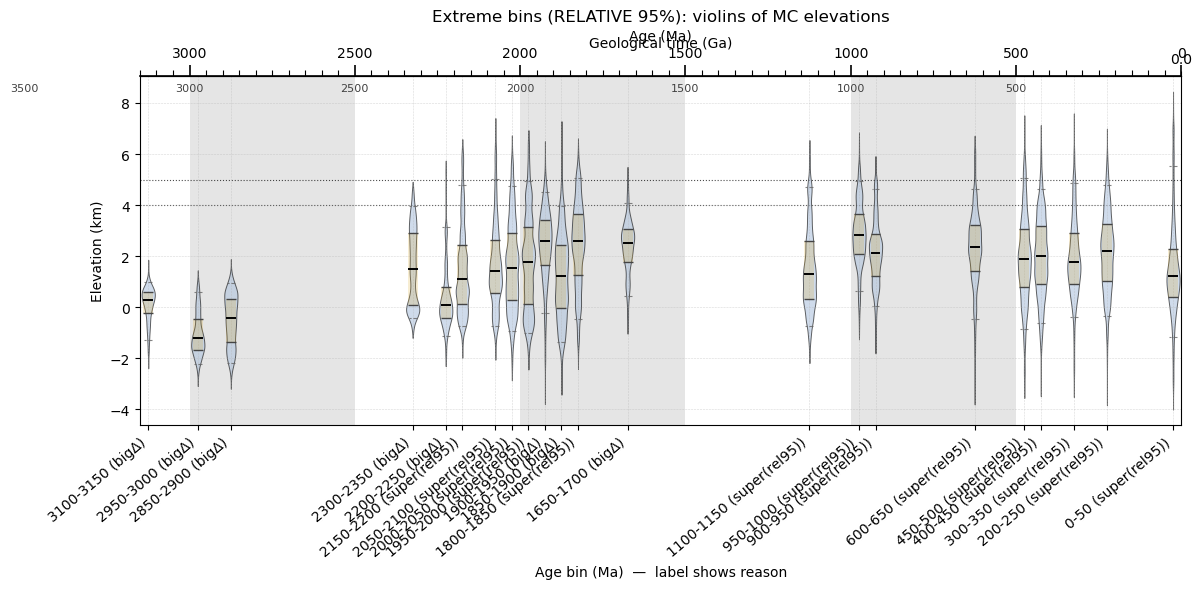

In [13]:
def plot_extreme_violins(
    df_mc,
    extreme_bins_df,
    age_col="Age_Ma",
    elev_col="Elevation_MC_km",
    bin_width_Ma=20.0,
    max_bins=None,              # None => show all
    order_by=None,              # e.g., "frac_ge_4.0km" or "p97_5_km"
    title="Distributions in extreme bins (violins)",
    figsize=(12,6),
    abs_lines=(4.0, 5.0),
    top_age_panel=True,
    top_major=500,
    top_minor=50,
    # NEW visual aids
    shade_iqr=True,             # translucent band for central 50%
    iqr_alpha=0.20,
    show_quartiles=True,        # horizontal lines at Q1, median, Q3
    quartile_lw=1.0,
    show_p95_lines=True,        # dashed whisker-style lines at p5/p95
    p95_alpha=0.8,
    p95_lw=0.8
):
    """
    Plot distributions for selected bins with interpretability overlays:
      • IQR shading (central 50%)
      • Q1 / median / Q3 horizontal lines
      • Optional p5/p95 whisker guides (dashed)
      • Top Age panel (numeric) like your screenshot
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    if extreme_bins_df.empty:
        raise ValueError("No extreme bins to plot.")

    # Ordering
    if order_by and (order_by in extreme_bins_df.columns):
        df_plot = extreme_bins_df.sort_values(order_by, ascending=False).copy()
    else:
        df_plot = extreme_bins_df.sort_values("bin_center_Ma", ascending=False).copy()

    if isinstance(max_bins, int):
        df_plot = df_plot.head(max_bins)

    # Collect per-bin arrays + stats
    data, positions, labels = [], [], []
    stats = []  # list of dicts per bin: {q1, med, q3, p5, p95}
    for _, row in df_plot.iterrows():
        left, right = float(row["bin_left_Ma"]), float(row["bin_right_Ma"])
        mask = (df_mc[age_col] >= left) & (df_mc[age_col] < right)
        vals = df_mc.loc[mask, elev_col].dropna().values
        if vals.size < 10:
            continue
        vals_sorted = np.sort(vals)
        q1, med, q3 = np.percentile(vals_sorted, [25, 50, 75])
        p5, p95 = np.percentile(vals_sorted, [5, 95])

        data.append(vals_sorted)
        positions.append(float(row["bin_center_Ma"]))
        reason = row.get("extreme_reason", row.get("extreme_reason_abs", ""))
        labels.append(f"{left:.0f}-{right:.0f} ({reason})")
        stats.append({"q1": q1, "med": med, "q3": q3, "p5": p5, "p95": p95})

    if not data:
        raise ValueError("No extreme bins with enough samples to plot.")

    fig, ax = plt.subplots(figsize=figsize)

    # Base violins
    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.8*bin_width_Ma,
        showmeans=False,
        showmedians=False,   # we’ll draw medians ourselves (thicker)
        showextrema=False
    )
    for pc in parts['bodies']:
        pc.set_facecolor("lightsteelblue")
        pc.set_edgecolor("black")
        pc.set_alpha(0.60)
        pc.set_linewidth(0.7)

    # Absolute guide lines (e.g., 4, 5 km)
    if abs_lines:
        for thr in abs_lines:
            ax.axhline(thr, color="0.3", lw=0.8, ls=":", zorder=0)

    # ======= Interpretability overlays =======
    # For consistent, readable overlay width (independent of KDE width),
    # use a slim rectangle around the bin center for IQR shading.
    halfw_overlay = 0.30 * bin_width_Ma

    for x0, s in zip(positions, stats):
        if shade_iqr:
            rect = Rectangle(
                (x0 - halfw_overlay, s["q1"]),
                2*halfw_overlay,
                s["q3"] - s["q1"],
                facecolor="goldenrod",
                edgecolor="none",
                alpha=iqr_alpha,
                zorder=2
            )
            ax.add_patch(rect)

        if show_quartiles:
            ax.hlines([s["q1"], s["med"], s["q3"]],
                      xmin=x0 - halfw_overlay,
                      xmax=x0 + halfw_overlay,
                      colors=["#444", "black", "#444"],
                      linestyles=["-", "-", "-"],
                      linewidths=[quartile_lw, quartile_lw+0.4, quartile_lw],
                      zorder=3)

        if show_p95_lines:
            ax.hlines([s["p5"], s["p95"]],
                      xmin=x0 - halfw_overlay*0.8,
                      xmax=x0 + halfw_overlay*0.8,
                      colors=["#666", "#666"],
                      linestyles=["--", "--"],
                      linewidths=[p95_lw, p95_lw],
                      alpha=p95_alpha,
                      zorder=2)

    # X ticks & labels
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=40, ha="right")
    ax.set_xlabel("Age bin (Ma)  —  label shows reason")
    ax.set_ylabel("Elevation (km)")
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

    # Optional background bands + GA axis
    if len(positions) > 1:
        try:
            draw_numeric_equal_bands(ax, min(positions), max(positions),
                                     step_ma=500, alpha=0.10, label=True, label_size=8)
        except Exception:
            pass
        try:
            _ = add_top_ga_axis(ax, positions, ga_tick_step=0.5)
        except Exception:
            pass

    # Top numeric Age panel like your screenshot
    if top_age_panel and len(positions) > 0:
        halfw = 0.5 * bin_width_Ma
        xmin, xmax = min(positions) - halfw, max(positions) + halfw
        try:
            add_age_panel_top(ax, xmin, xmax, major=top_major, minor=top_minor, label="Age (Ma)")
        except Exception:
            pass

    ax.invert_xaxis()
    fig.tight_layout()
    return fig, ax

fig_vio_rel95, ax = plot_extreme_violins(
    df_mc, extreme_bins_rel95,
    bin_width_Ma=(bin_width_override or suggested_width),
    max_bins=None, order_by=None,
    title="Extreme bins (RELATIVE 95%): violins of MC elevations",
    figsize=(12,6), abs_lines=(4.0, 5.0),
    shade_iqr=True,
    show_quartiles=True,
    show_p95_lines=True
)

# Save as PDF
fig_vio_rel95.savefig(
    "extreme_bins_violin_plot.pdf",
    format="pdf",
    bbox_inches="tight"
)
